# Visualisasi Data Statistik dengan Seaborn

Setelah mempelajari Matplotlib di materi sebelumnya, pertanyaan yang sering muncul adalah:
> *"Kalau Matplotlib sudah bisa menggambar grafik apa saja, kenapa kita masih butuh Seaborn?"*

Perbedaannya terletak pada **level abstraksi** dan **kemudahan integrasi statistik**:
* **Matplotlib** bekerja di tingkat dasar (*low-level*). Anda harus mengatur setiap detail garis, warna, jarak batang, dan legenda secara manual. Ibaratnya, Anda merakit sepeda motor dari nol menggunakan baut dan obeng.
* **Seaborn** adalah pustaka visualisasi tingkat tinggi (*high-level*) yang dibangun tepat di atas Matplotlib. Seaborn dirancang khusus untuk bekerja langsung dengan **DataFrame Pandas**. Dengan hanya satu baris kode pendek, Seaborn otomatis menerapkan palet warna yang modern, mengelompokkan data berdasarkan kategori, dan menghitung estimasi statistik (seperti rata-rata, distribusi probabilitas, dan interval kepercayaan).

Singkatnya: Matplotlib memberikan **kebebasan kendali penuh**, sedangkan Seaborn memberikan **keindahan visual dan analisis statistik instan**.

## 1. Memasang Pustaka Seaborn

Pastikan pustaka Seaborn sudah terpasang di komputer Anda sebelum memulai:

In [1]:
! pip install seaborn

     -------------------------------------- 294.9/294.9 kB 2.3 MB/s eta 0:00:00



[notice] A new release of pip available: 22.2.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Setup Tema dan Menyiapkan Dataset Realistis

Seaborn memiliki fungsi `sns.set_theme(style="whitegrid")` yang otomatis mengubah tampilan grafik menjadi bersih, modern, dan profesional tanpa perlu mengatur font atau garis kisi satu per satu.

Mari kita siapkan contoh dataset transaksi toko daring berisi informasi kategori barang, harga, unit terjual, metode pembayaran, dan rating pembeli:

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Mengatur tema visual bersih bawaan Seaborn
sns.set_theme(style="whitegrid")

# Membuat dataset transaksi e-commerce
data_transaksi = pd.DataFrame({
    'Kategori': ['Komputer', 'Komputer', 'Aksesoris', 'Aksesoris', 'Audio', 'Audio', 'Komputer', 'Aksesoris', 'Audio', 'Komputer', 'Aksesoris', 'Audio'],
    'Harga_Ribu': [8500, 12000, 150, 450, 800, 1500, 9200, 250, 1100, 7800, 350, 1800],
    'Terjual': [15, 8, 85, 40, 30, 22, 12, 60, 25, 18, 50, 19],
    'Metode_Bayar': ['Transfer', 'QRIS', 'QRIS', 'Cash', 'QRIS', 'Transfer', 'Transfer', 'Cash', 'QRIS', 'Transfer', 'QRIS', 'Transfer'],
    'Rating': [4.8, 4.9, 4.5, 4.7, 4.3, 4.6, 4.7, 4.4, 4.5, 4.6, 4.8, 4.7]
})

print("Tabel Transaksi (5 Baris Pertama):")
print(data_transaksi.head())

Tabel Transaksi (5 Baris Pertama):
    Kategori  Harga_Ribu  Terjual Metode_Bayar  Rating
0   Komputer        8500       15     Transfer     4.8
1   Komputer       12000        8         QRIS     4.9
2  Aksesoris         150       85         QRIS     4.5
3  Aksesoris         450       40         Cash     4.7
4      Audio         800       30         QRIS     4.3


## 3. Kekuatan Parameter `hue`: Membedah Data Multi-Kategori

Salah satu fitur paling dicintai di Seaborn adalah parameter **`hue`**.

Dengan parameter `hue`, kita bisa memecah grafik batang per kategori berdasarkan dimensi tambahan (misalnya metode pembayaran) hanya dengan mengetik `hue='Metode_Bayar'`. Seaborn akan otomatis membuat warna berbeda dan menyusun legendanya secara rapi:

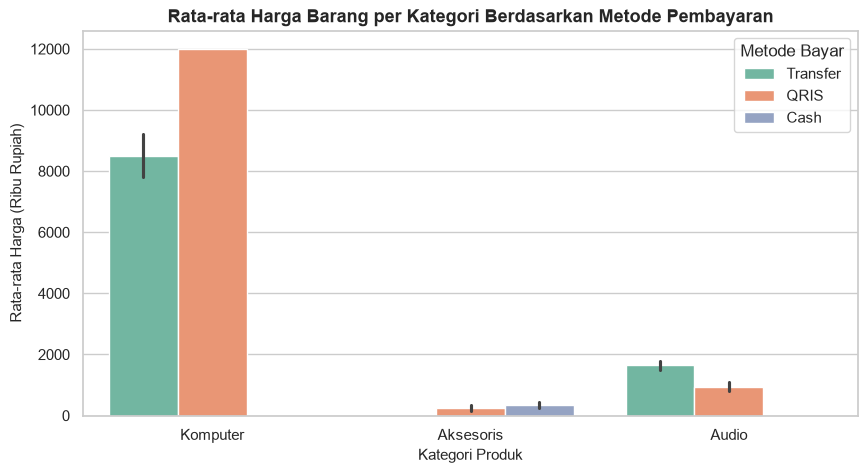

In [3]:
plt.figure(figsize=(10, 5))

# Barplot dengan pengelompokan warna berdasarkan Metode Pembayaran
sns.barplot(
    data=data_transaksi,
    x='Kategori',
    y='Harga_Ribu',
    hue='Metode_Bayar',
    palette='Set2'
)

plt.title('Rata-rata Harga Barang per Kategori Berdasarkan Metode Pembayaran', fontsize=13, fontweight='bold')
plt.xlabel('Kategori Produk', fontsize=11)
plt.ylabel('Rata-rata Harga (Ribu Rupiah)', fontsize=11)
plt.legend(title='Metode Bayar')
plt.show()

## 4. Histogram & Kurva Kepadatan Probabilitas (`kde=True`)

Saat menganalisis variabel kontinu (seperti skor rating atau usia pelanggan), kita ingin tahu apakah data tersebut condong ke arah kanan, kiri, atau simetris di tengah.

Dengan menambahkan opsi `kde=True` (*Kernel Density Estimate*), Seaborn akan menggambar kurva mulus di atas histogram untuk memperkirakan bentuk sebaran populasinya:

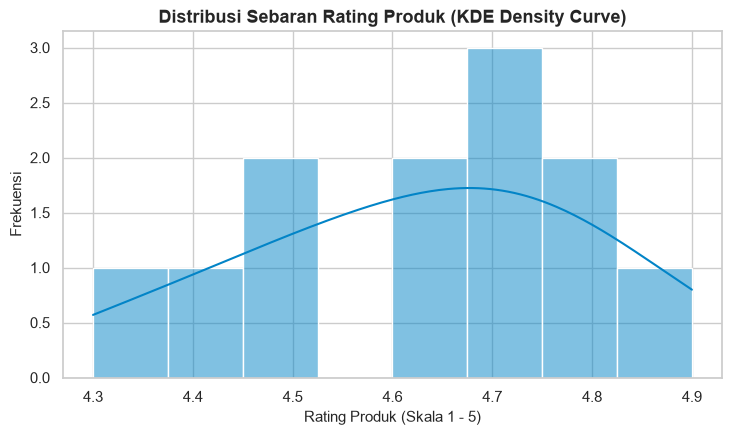

In [4]:
plt.figure(figsize=(8.5, 4.5))

# Histogram dengan estimasi kurva mulus KDE
sns.histplot(
    data=data_transaksi,
    x='Rating',
    kde=True,
    color='#0284c7',
    bins=8
)

plt.title('Distribusi Sebaran Rating Produk (KDE Density Curve)', fontsize=13, fontweight='bold')
plt.xlabel('Rating Produk (Skala 1 - 5)', fontsize=11)
plt.ylabel('Frekuensi', fontsize=11)
plt.show()

## 5. Boxplot: Memahami Distribusi Kuartil dan Mendeteksi Outlier

**Diagram Kotak Garis (*Boxplot*)** adalah salah satu alat paling penting bagi seorang praktisi data. Dari satu kotak kecil ini, kita bisa langsung membaca lima ringkasan statistik sekaligus:
1. **Garis tengah di dalam kotak**: Nilai Median (Q2 / kuartil tengah).
2. **Batas bawah & atas kotak**: Kuartil 1 (Q1 - 25% data) dan Kuartil 3 (Q3 - 75% data). Kotak ini merangkum 50% data utama Anda.
3. **Garis kumis (*whiskers*)**: Batas rentang data wajar terendah dan tertinggi.
4. **Titik-titik terisolasi di luar kumis**: **Outlier (Nilai Pencilan)**, yaitu data ekstrem yang jauh berbeda dari mayoritas populasi.

C:\Users\iputu\AppData\Local\Temp\ipykernel_16124\4147858169.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


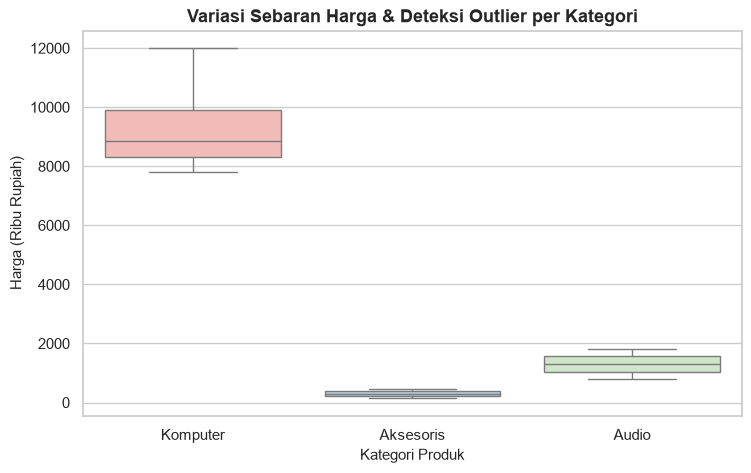

In [5]:
plt.figure(figsize=(8.5, 5))

# Boxplot variasi harga per kategori barang
sns.boxplot(
    data=data_transaksi,
    x='Kategori',
    y='Harga_Ribu',
    palette='Pastel1'
)

plt.title('Variasi Sebaran Harga & Deteksi Outlier per Kategori', fontsize=13, fontweight='bold')
plt.xlabel('Kategori Produk', fontsize=11)
plt.ylabel('Harga (Ribu Rupiah)', fontsize=11)
plt.show()

## 6. Scatter Plot Multi-Dimensi (Posisi, Warna, dan Ukuran)

Di Seaborn, kita bisa memvisualisasikan hingga **4 variabel sekaligus** dalam satu grafik sebar (*scatter plot*):
* Sumbu X: Harga Barang
* Sumbu Y: Jumlah Unit Terjual
* Warna (`hue`): Kategori Produk
* Ukuran Titik (`size`): Skor Rating

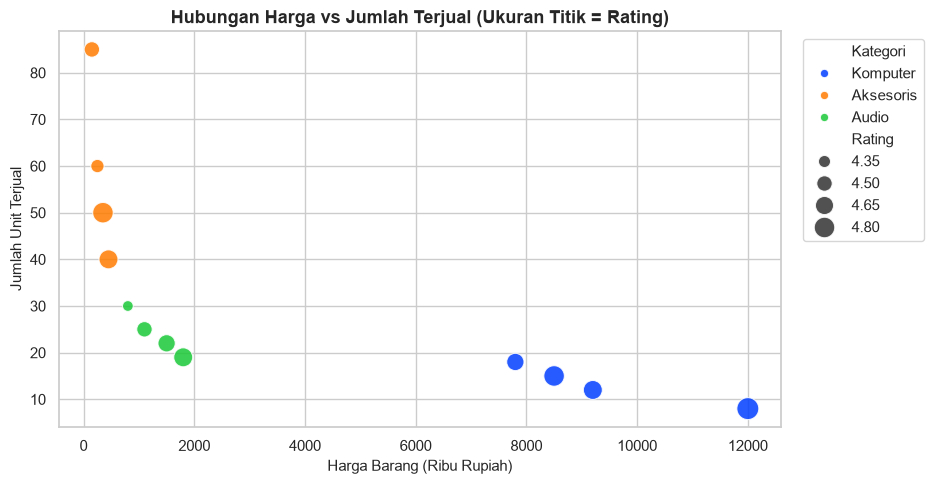

In [6]:
plt.figure(figsize=(9.5, 5))

sns.scatterplot(
    data=data_transaksi,
    x='Harga_Ribu',
    y='Terjual',
    hue='Kategori',
    size='Rating',
    sizes=(60, 250),
    palette='bright',
    alpha=0.85
)

plt.title('Hubungan Harga vs Jumlah Terjual (Ukuran Titik = Rating)', fontsize=13, fontweight='bold')
plt.xlabel('Harga Barang (Ribu Rupiah)', fontsize=11)
plt.ylabel('Jumlah Unit Terjual', fontsize=11)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')  # Meletakkan legenda di luar grafik
plt.tight_layout()
plt.show()

## 7. Heatmap Korelasi: Peta Panas Hubungan Antar Variabel Numerik

Dalam tahap **Analisis Data Eksploratif (EDA)** dan pembuatan model Machine Learning, langkah nomor satu yang hampir selalu dilakukan adalah memeriksa **matriks korelasi** antar seluruh kolom angka.

Korelasi berkisar antara `-1` (berbanding terbalik sempurna) hingga `+1` (berbanding lurus sempurna). Angka mendekati `0` berarti tidak ada hubungan linear.

Dengan fungsi `sns.heatmap()`, angka-angka korelasi ini diubah menjadi gradasi warna visual yang langsung menunjukkan variabel mana yang saling mempengaruhi:

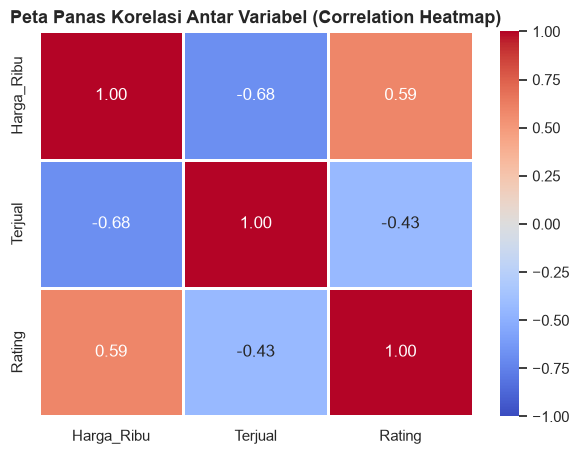

In [7]:
# Mengambil hanya kolom-kolom angka numerik
kolom_numerik = data_transaksi[['Harga_Ribu', 'Terjual', 'Rating']]

# Menghitung tabel matriks korelasi Pearson
matriks_korelasi = kolom_numerik.corr()

plt.figure(figsize=(7, 5))

# Menggambar heatmap dengan label angka (annot=True)
sns.heatmap(
    matriks_korelasi,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=1,
    vmin=-1,
    vmax=1
)

plt.title('Peta Panas Korelasi Antar Variabel (Correlation Heatmap)', fontsize=13, fontweight='bold')
plt.show()